# 02 - Preprocessing


This notebook preprocesses the UNSW_NB15 dataset for anomaly detection.

**Main goals :**

1. Handle missing values
2. Encode categorical features
3. Normalize numerical features
4. Split data for anomaly detection


## 0 - Imports and configuration


In [1]:
#Imports 

import sys
sys.path.append('../src')

In [2]:
#Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from data_loader import load_unsw_data, get_feature_types

from preprocessing import (
    handle_missing_values,
    encode_categorical_features,
    normalize_features,
    split_for_anomaly_detection,
    save_preprocessed_data
)

#Plot configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("All good!")

All good!


## 1 - Data loading


In [3]:
df_train_orig = load_unsw_data(data_dir = '../data/archive', dataset = 'training')
df_test_orig = load_unsw_data(data_dir = '../data/archive', dataset = 'testing')

print(f"\nOriginal shapes :")
print(f"  Training : {df_train_orig.shape}")
print(f"  Testing : {df_test_orig.shape}")

#Remove duplicates (there are many in the training set, and some in the test set)
print(f"\nRemoving duplicates :")
print(f"  Training duplicates : {df_train_orig.duplicated().sum()}")
print(f"  Testing duplicates : {df_test_orig.duplicated().sum()}")

df_train_orig = df_train_orig.drop_duplicates().reset_index(drop = True)
df_test_orig = df_test_orig.drop_duplicates().reset_index(drop = True)

print(f"\nAfter deduplication :")
print(f"  Training : {df_train_orig.shape}")
print(f"  Testing : {df_test_orig.shape}")

df_train_normal = df_train_orig[df_train_orig['label'] == 0].copy()
df_train_attack = df_train_orig[df_train_orig['label'] == 1].copy()

df_train = pd.concat([df_train_normal, df_test_orig, df_train_attack], ignore_index = True)

print(f"\nCombined data : {df_train.shape}")
print(f"  Normal : {sum(df_train['label'] == 0)}")
print(f"  Attack : {sum(df_train['label'] == 1)}")

print(f"\nColumns : {df_train.columns.tolist()[:10]}...")

Loading ../data/archive/UNSW_NB15_training-set.parquet...
Loaded 175341 rows and 36 columns.
Loading ../data/archive/UNSW_NB15_testing-set.parquet...
Loaded 82332 rows and 36 columns.

Original shapes :
  Training : (175341, 36)
  Testing : (82332, 36)

Removing duplicates :


  Training duplicates : 78519
  Testing duplicates : 32361

After deduplication :
  Training : (96822, 36)
  Testing : (49971, 36)



Combined data : (146793, 36)
  Normal : 80504
  Attack : 66289

Columns : ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload']...


## 2 - Identify feature types


In [4]:
feature_types = get_feature_types(df_train)

print(f"Numerical features : {len(feature_types['numerical'])}")
print(f"Categorical features : {len(feature_types['categorical'])}")
print(f"\nCategorical features : {feature_types['categorical']}")


Numerical features : 32
Categorical features : 4

Categorical features : ['proto', 'service', 'state', 'attack_cat']


## 3 - Remove unnecessary columns


We remove columns that won't be useful for the autoencoder :

- IP adresses
- Attack category (since we'll only use binary labelling)


In [5]:
cols_to_drop = []
ip_cols = [col for col in df_train.columns if 'ip' in col.lower()] #.lower() to catch 'IP' or 'ip'.
cols_to_drop.extend(ip_cols)

if 'attack_cat' in df_train.columns:
    cols_to_drop.append('attack_cat')

id_cols = [col for col in df_train.columns if 'id' in col.lower()]
cols_to_drop.extend(id_cols)

print(f"Columns to drop : {cols_to_drop}")

df_clean = df_train.drop(columns = cols_to_drop, errors = 'ignore')
print(f"\nShape after dropping columns: {df_clean.shape}")

Columns to drop : ['is_sm_ips_ports', 'attack_cat']

Shape after dropping columns: (146793, 34)


## 4 - Handle missing values


In [6]:
missing = df_clean.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
  print("Columns with missing values:")
  for col, count in missing.items():
    percentage = (count / len(df_clean)) * 100
    print(f" {col}: {count} missing values ({percentage:.2f}%)")
  df_clean = handle_missing_values(df_clean, strategy='median')
else: 
  print("No missing values.")

No missing values.


## 5 - Encode categorical features


In [7]:
categorical_cols = [col for col in feature_types['categorical'] if col in df_clean.columns and col != 'label']
print(f"\nEncoding categorical features: {categorical_cols}")

if len(categorical_cols) > 0:
  df_encoded, encoders = encode_categorical_features(df_clean, categorical_cols, method = 'label')
else:
  df_encoded = df_clean
  encoders = {}
  print("No categorical features to encode.")

print(f"\nShape after encoding: {df_encoded.shape}")


Encoding categorical features: ['proto', 'service', 'state']
Label encoded 3 categorical features

Shape after encoding: (146793, 34)


## 6 - Split data for anomaly detection

**Reminder :**

Split data into train/validation/test sets for anomaly detection.

- Train -> Only normal data.
- Validation -> Only normal data.
- Test -> Mix of normal and anomalous data.


Data split summary :
Train set :  52327 samples (100% normal)
Validation set :  12075 samples (100% normal)
Test set :  82391 samples (16102 normal, 66289 attacks)
  Val normal : 12075, attacks : 0
  Test normal : 16102, attacks : 66289


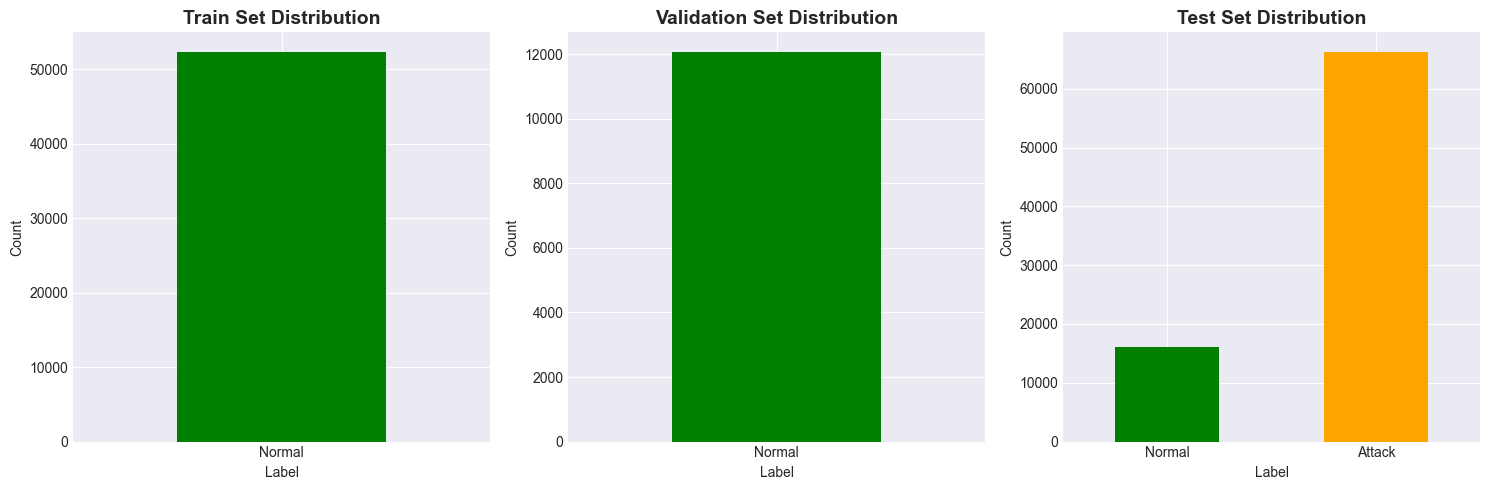

In [8]:
from preprocessing import split_for_anomaly_detection

#Data splitting
X_train, X_val, X_test, y_train, y_val, y_test = split_for_anomaly_detection(
    df_encoded,
    label_col = 'label',
    val_size = 0.15,
    test_size = 0.20,
    random_state = 42
)

print(f"  Val normal : {sum(y_val == 0)}, attacks : {sum(y_val == 1)}")
print(f"  Test normal : {sum(y_test == 0)}, attacks : {sum(y_test == 1)}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

# Training set
train_counts = pd.Series(y_train).value_counts().sort_index()
train_counts.plot(kind = 'bar', ax = axes[0], color = ['green'])
axes[0].set_title('Train Set Distribution', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Normal'], rotation = 0)
# Validation set
val_counts = pd.Series(y_val).value_counts().sort_index()
val_counts.plot(kind = 'bar', ax = axes[1], color = ['green'])
axes[1].set_title('Validation Set Distribution', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Normal'], rotation = 0)
# Test set
test_counts = pd.Series(y_test).value_counts().sort_index()
test_counts.plot(kind = 'bar', ax = axes[2], color = ['green', 'orange'])
axes[2].set_title('Test Set Distribution', fontsize = 14, fontweight = 'bold')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(['Normal', 'Attack'], rotation = 0)
plt.tight_layout()
plt.show()

## 7 - Normalize features


In [9]:
feature_cols = [col for col in X_train.columns]

print(f"Features to normalize : {len(feature_cols)}")

X_train_norm, scaler = normalize_features(X_train, feature_cols)
X_val_norm, _ = normalize_features(X_val, feature_cols, scaler = scaler)
X_test_norm, _ = normalize_features(X_test, feature_cols, scaler = scaler)

print("\nPreprocessing complete.")

Features to normalize : 33
Successfully fitted and transformed 33 features
Successfully transformed 33 features using provided scaler
Successfully transformed 33 features using provided scaler

Preprocessing complete.



Train set statistics after normalization :
  Mean : 0.000000
  Std :  1.000010


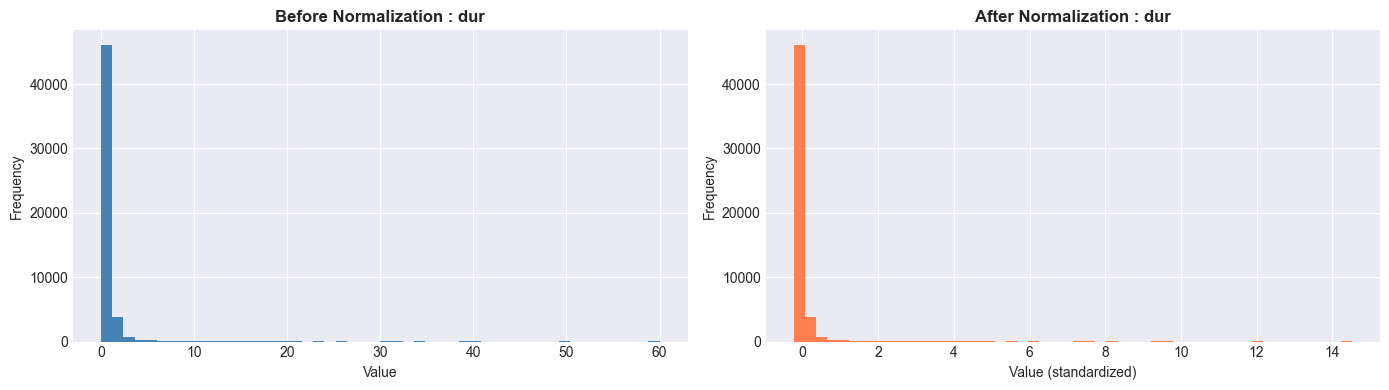

In [10]:
# Verify normalization
print("\nTrain set statistics after normalization :")
print(f"  Mean : {X_train_norm.mean().mean():.6f}") #Should be close to 0.
print(f"  Std :  {X_train_norm.std().mean():.6f}") #Should be close to 1.

# Visualize before/after normalization
fig, axes = plt.subplots(1, 2, figsize = (14, 4))

# Before normalization
sample_col = X_train.columns[0]
X_train[sample_col].hist(bins = 50, ax = axes[0], color = 'steelblue')
axes[0].set_title(f'Before Normalization : {sample_col}', fontweight = 'bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

# After normalization
X_train_norm[sample_col].hist(bins = 50, ax = axes[1], color = 'coral')
axes[1].set_title(f'After Normalization : {sample_col}', fontweight = 'bold')
axes[1].set_xlabel('Value (standardized)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 8 - Save preprocessed data


In [11]:
save_preprocessed_data(X_train_norm, X_val_norm, X_test_norm, 
                       y_train, y_val, y_test,
                       scaler, encoders, 
                       output_dir = '../data/processed')


- X_train.npy : (52327, 33), X_val.npy : (12075, 33), X_test.npy : (82391, 33)
- y_train.npy : (52327,), y_val.npy : (12075,), y_test.npy : (82391,)
- scaler.pkl, encoders.pkl, feature_names.pkl


## 9 - Summary


In [12]:
print("Summary :")

print(f"\n1. Original data :")
print(f"- Shape : {df_train.shape}")

print(f"\n2. Final data :")
print(f"- Train : {X_train_norm.shape} (100% normal)")
print(f"- Validation : {X_val_norm.shape} ({(y_val == 0).sum()} normal, {(y_val == 1).sum()} attacks)")
print(f"- Test : {X_test_norm.shape} ({(y_test == 0).sum()} normal, {(y_test == 1).sum()} attacks)")

Summary :

1. Original data :
- Shape : (146793, 36)

2. Final data :
- Train : (52327, 33) (100% normal)
- Validation : (12075, 33) (12075 normal, 0 attacks)
- Test : (82391, 33) (16102 normal, 66289 attacks)
